# Practical 7 - Decision Tree Classification on Titanic Dataset

**Aim:** Perform decision tree classification on the Titanic dataset.

Keep `train.csv` in the same folder as this notebook.

In [1]:
!pip install pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

print(os.getcwd())
titanic_df = pd.read_csv("train.csv")
titanic_df.head()

c:\Users\anand\Downloads\DS_Practicals_Extracted


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch"]
X = titanic_df[features].copy()
print(X)
X.info()

     Pclass     Sex   Age  SibSp  Parch
0         3    male  22.0      1      0
1         1  female  38.0      1      0
2         3  female  26.0      0      0
3         1  female  35.0      1      0
4         3    male  35.0      0      0
..      ...     ...   ...    ...    ...
886       2    male  27.0      0      0
887       1  female  19.0      0      0
888       3  female   NaN      1      2
889       1    male  26.0      0      0
890       3    male  32.0      0      0

[891 rows x 5 columns]
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  891 non-null    int64  
 1   Sex     891 non-null    str    
 2   Age     714 non-null    float64
 3   SibSp   891 non-null    int64  
 4   Parch   891 non-null    int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 34.9 KB


In [5]:
Y = titanic_df["Survived"]
Y.info()
Y.head()

<class 'pandas.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Survived
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [6]:
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
X.head()

X["Age"] = X["Age"].fillna(X["Age"].median())
X.isnull().sum()

Pclass    0
Sex       0
Age       0
SibSp     0
Parch     0
dtype: int64

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=10)

dtmodel = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=10)
dtmodel.fit(X_train, Y_train)

Y_pred = dtmodel.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy: 0.8379888268156425
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       117
           1       0.77      0.76      0.76        62

    accuracy                           0.84       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.84      0.84      0.84       179



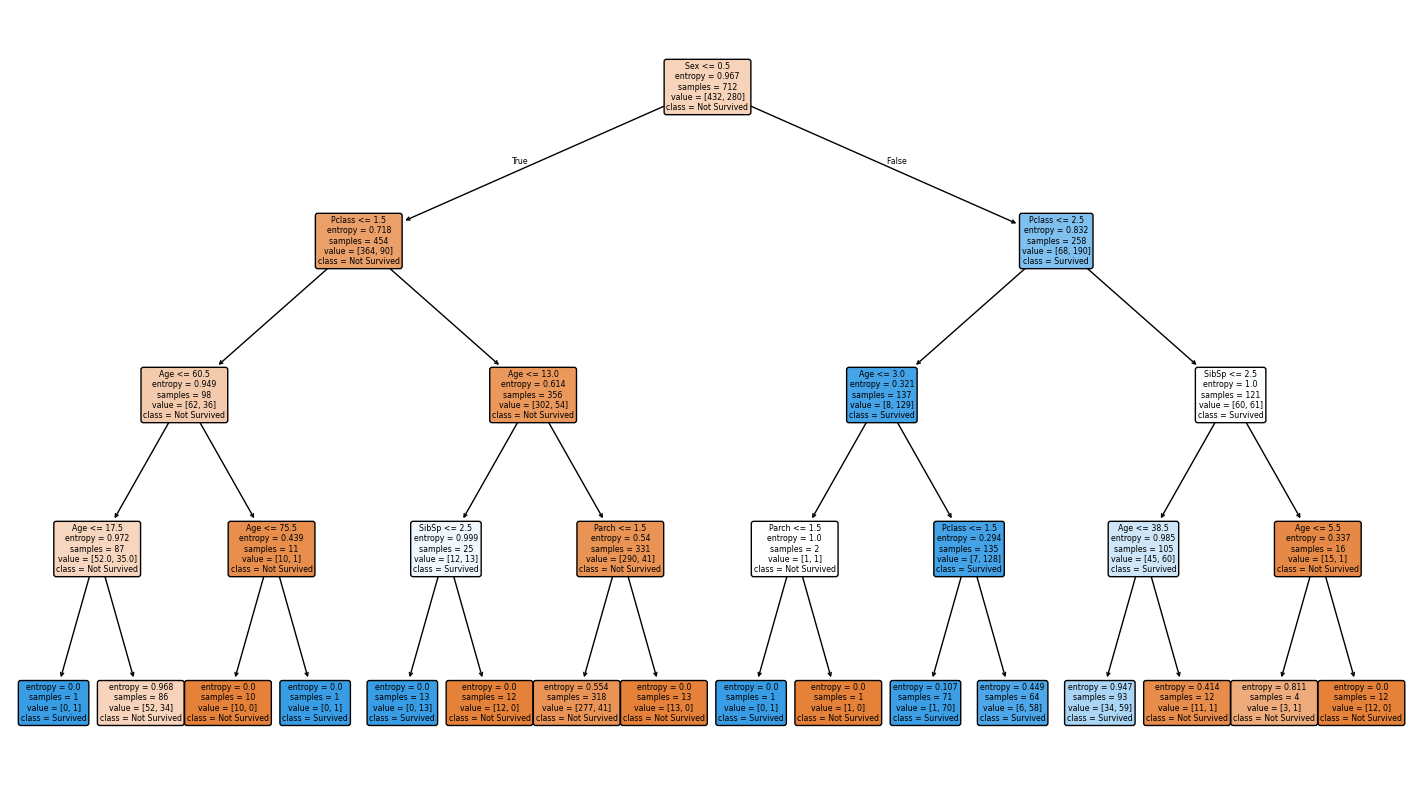

In [8]:
plt.figure(figsize=(18, 10))
plot_tree(
    dtmodel,
    feature_names=features,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True
)
plt.show()

This notebook selects a few Titanic features, converts the `Sex` column into numbers, and fills missing age values using the median.  
A decision tree classifier is then trained on the processed data and tested on unseen records.  
Finally, it prints the accuracy, classification report, and draws the full decision tree for interpretation.